In [1]:
import wandb
import pandas as pd

api = wandb.Api()

entity = "theme4"
project = "aramco_dac"
runs = api.runs(f"{entity}/{project}")

results = []

# runs_id = [
#     "wqc3aava", # MT[DB1+DB2]_TMP[2.0]
# ]

target_runs = [
    'MT[DB1]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB1]',
    'MT[DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB2]',
    # 'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[temp_1.0]',
    'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[temp_2.0]',
    # 'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[uniform_sampling]',
]

for run in runs:
    if run.name not in target_runs:
        continue
    if "MT" not in run.name or "2targets" in run.name:
        continue  # Skip runs without "DB1" in their name

    run_info = {
        "run_id": run.id,
        "run_name": run.name,
    }

    # Extract all test/ keys from the summary
    for key, value in run.summary._json_dict.items():
        if key.startswith("test/") and isinstance(value, (float, int)):
            run_info[key] = value

    results.append(run_info)

# Convert to DataFrame and save
df = pd.DataFrame(results).dropna(axis=0, how='any')
df.to_csv("val_metrics_DB1_only.csv", index=False)
print("Saved test/ metrics for DB1 runs to val_metrics_DB1_only.csv")

Saved test/ metrics for DB1 runs to val_metrics_DB1_only.csv


In [2]:
df

,run_id,run_name,test/adsorption_db/adsorption_db_1/co2_uptake_mae,test/adsorption_db/adsorption_db_1/co2_uptake_mape,test/adsorption_db/adsorption_db_1/co2_uptake_smape,test/adsorption_db/adsorption_db_1/kh_co2_mae,test/adsorption_db/adsorption_db_1/kh_co2_mape,test/adsorption_db/adsorption_db_1/kh_co2_smape,test/adsorption_db/adsorption_db_1/qst_co2_mae,test/adsorption_db/adsorption_db_1/qst_co2_mape,test/adsorption_db/adsorption_db_1/qst_co2_smape,test/adsorption_db/adsorption_db_2/co2_uptake_mae,test/adsorption_db/adsorption_db_2/co2_uptake_mape,test/adsorption_db/adsorption_db_2/co2_uptake_smape,test/adsorption_db/adsorption_db_2/kh_co2_mae,test/adsorption_db/adsorption_db_2/kh_co2_mape,test/adsorption_db/adsorption_db_2/kh_co2_smape,test/adsorption_db/adsorption_db_2/qst_co2_mae,test/adsorption_db/adsorption_db_2/qst_co2_mape,test/adsorption_db/adsorption_db_2/qst_co2_smape
0,iqx79ukq,MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10...,0.000843,2.280659,0.453604,0.000020,1.049108,0.447876,2.039712,0.093106,0.095255,0.000491,0.224977,0.213955,0.000012,0.347537,0.303128,0.678276,0.031234,0.031621
1,xjwo2igj,MT[DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml...,0.002298,5.899100,0.850000,0.000049,3.638726,0.852051,11.514448,0.482813,0.354277,0.000477,0.221069,0.225734,0.000011,0.261650,0.265866,0.666030,0.030729,0.031132
2,dxsbsc54,MT[DB1]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml...,0.000969,2.470963,0.548541,0.000024,1.250499,0.561329,2.330036,0.107958,0.109684,0.006450,8.456178,1.809723,0.001076,64.583588,1.892777,4.395350,0.193553,0.221533


In [3]:
df.run_name.tolist()  

['MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[temp_2.0]',
 'MT[DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB2]',
 'MT[DB1]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB1]']

In [4]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import scienceplots
import re

# Style and palette
plt.style.use(['science', 'no-latex'])
colors = sns.color_palette("Set2")
plt.rcParams.update({
    "font.size": 18,         
    "axes.titlesize": 20,    
    "axes.labelsize": 18,    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.ticker import FuncFormatter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.ticker import FuncFormatter

# Read CSV
csv_path = "val_metrics_DB1_only.csv"
df = pd.read_csv(csv_path)

# Keep only the specified runs
# target_runs = [
#     'MT[DB1]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB1]',
#     'MT[DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[DB2]',
#     'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[uniform_sampling]',
#     'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[temp_2.0]',
#     'MT[DB1+DB2]_3targets_ep15_LR8e-05_PT[jmp]_bs10_sml_gemnet_MTS[temp_1.0]',
# ]
df = df[df["run_name"].isin(target_runs)].copy()

# Extract dataset group from MT[...] and sampling strategy from MTS[...]
df["dataset_group"] = df["run_name"].str.extract(r"MT\[(DB1\+DB2|DB1|DB2)\]")
df["sampling_strategy"] = df["run_name"].str.extract(r"MTS\[(.*?)\]")

# Rename for nicer display
strategy_rename = {
    "DB1": "Only DB1",
    "DB2": "Only DB2",
    "temp_1.0": "Temp 1.0",
    "temp_2.0": "Temp 2.0",
    "uniform_sampling": "Uniform",
}
df["sampling_strategy"] = df["sampling_strategy"].map(strategy_rename)
df["dataset_group"] = df["dataset_group"].replace({
    "DB1": "DB1",
    "DB2": "DB2",
    "DB1+DB2": "Joint [DB1 + DB2]",
})

# Select metric columns
mae_cols = [c for c in df.columns if "mae" in c and c.startswith("test/adsorption_db/")]
smape_cols = [c for c in df.columns if "smape" in c and c.startswith("test/adsorption_db/")]

# Melt into long format
mae_df = df.melt(id_vars=["dataset_group", "sampling_strategy"], value_vars=mae_cols,
                 var_name="metric", value_name="value")
smape_df = df.melt(id_vars=["dataset_group", "sampling_strategy"], value_vars=smape_cols,
                   var_name="metric", value_name="value")

# Clean metric names
mae_df["metric"] = mae_df["metric"].str.replace("test/adsorption_db/", "").str.replace("_mae", "")
smape_df["metric"] = smape_df["metric"].str.replace("test/adsorption_db/", "").str.replace("_smape", "")
smape_df["value"] *= 100

# Mapping
metric_rename = {
    "adsorption_db_1/qst_co2": r"DB1: CO$_2$ Qst",
    "adsorption_db_1/kh_co2": r"DB1: CO$_2$ KH",
    "adsorption_db_1/co2_uptake": r"DB1: CO$_2$ Uptake",
    "adsorption_db_2/qst_co2": r"DB2: CO$_2$ Qst",
    "adsorption_db_2/kh_co2": r"DB2: CO$_2$ KH",
    "adsorption_db_2/co2_uptake": r"DB2: CO$_2$ Uptake",
}



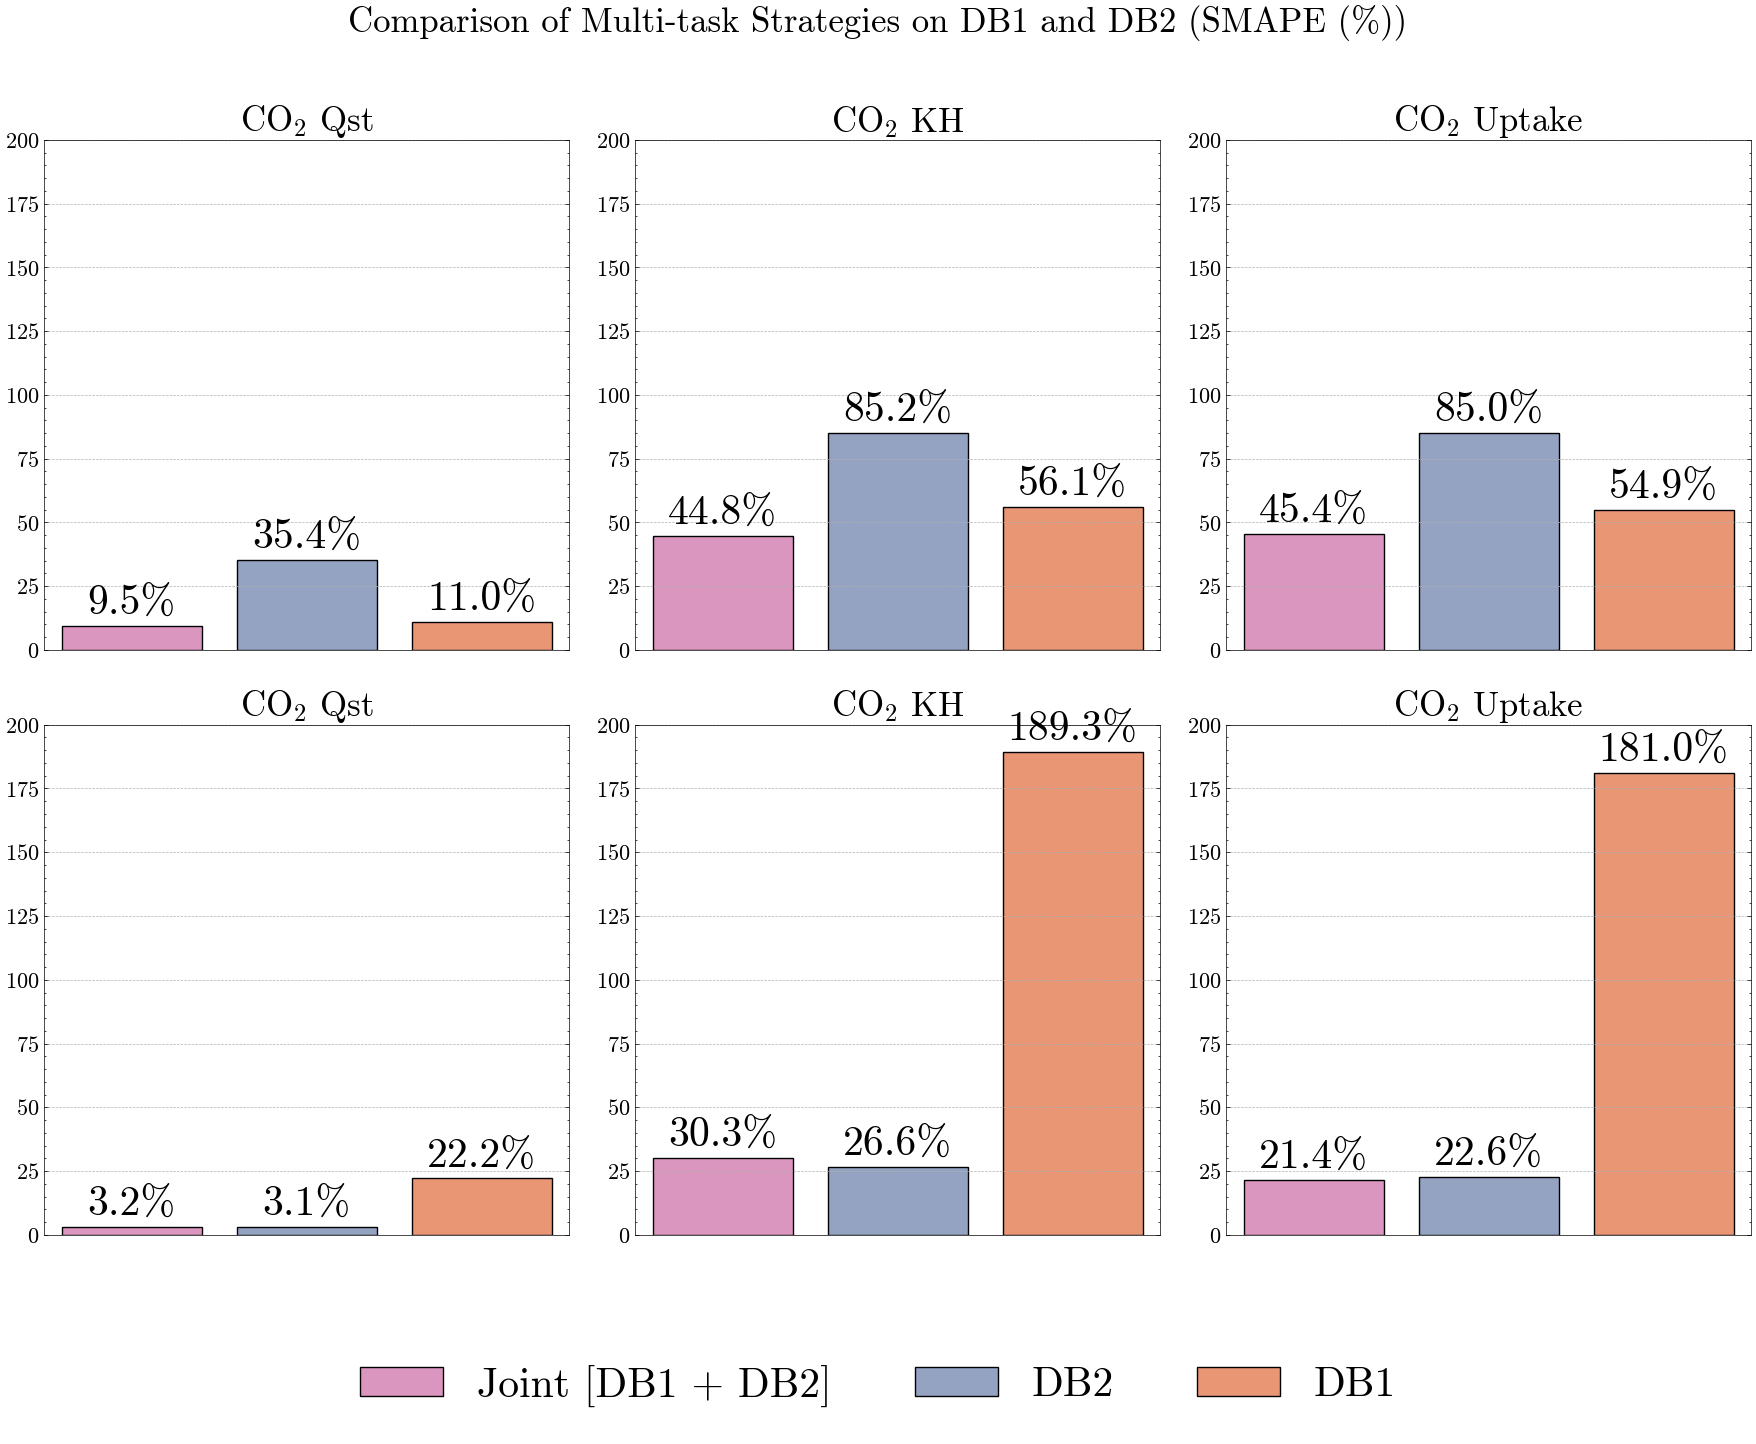

In [5]:
def plot_metrics(df, metric_type="SMAPE (%)"):
    metrics_ordered = [
        "adsorption_db_1/qst_co2",
        "adsorption_db_1/kh_co2",
        "adsorption_db_1/co2_uptake",
        "adsorption_db_2/qst_co2",
        "adsorption_db_2/kh_co2",
        "adsorption_db_2/co2_uptake",
    ]

    # metric_rename = {
    #     "adsorption_db_1/qst_co2": r"Evaluation DB1: CO$_2$ Qst",
    #     "adsorption_db_1/kh_co2": r"Evaluation DB1: CO$_2$ KH",
    #     "adsorption_db_1/co2_uptake": r"Evaluation DB1: CO$_2$ Uptake",
    #     "adsorption_db_2/qst_co2": r"Evaluation DB2: CO$_2$ Qst",
    #     "adsorption_db_2/kh_co2": r"Evaluation DB2: CO$_2$ KH",
    #     "adsorption_db_2/co2_uptake": r"Evaluation on DB2: CO$_2$ Uptake",
    # }
    metric_rename = {
        "adsorption_db_1/qst_co2": r"CO$_2$ Qst",
        "adsorption_db_1/kh_co2": r"CO$_2$ KH",
        "adsorption_db_1/co2_uptake": r"CO$_2$ Uptake",
        "adsorption_db_2/qst_co2": r"CO$_2$ Qst",
        "adsorption_db_2/kh_co2": r"CO$_2$ KH",
        "adsorption_db_2/co2_uptake": r"CO$_2$ Uptake",
    }
    custom_palette = {
        "DB1": "#FC8D62",
        "DB2": "#8DA0CB",
        "Joint [DB1 + DB2]": "#E78AC3",
    }

    fig, axs = plt.subplots(2, 3, figsize=(18, 15))
    axs = axs.flatten()

    handles, labels = None, None

    for i, metric in enumerate(metrics_ordered):
        subset = df[df["metric"] == metric]
        ax = axs[i]

        barplot = sns.barplot(
            data=subset,
            x="sampling_strategy",
            y="value",
            hue="dataset_group",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1.0,
            ax=ax
        )

        ax.set_title(metric_rename[metric], fontsize=25)
        ax.set_ylabel("")
        ax.set_ylim([0, 200])
        ax.set_xlabel("")
        ax.set_xticks([])
        # ax.tick_params(axis="x", rotation=15)
        ax.grid(True, linestyle="--", linewidth=0.5)

        if handles is None and labels is None:
            handles, labels = ax.get_legend_handles_labels()

        ax.legend_.remove()

        for container in barplot.containers:
            if metric_type.lower().startswith("smape"):
                labels_ = [f"{bar.get_height():.1f}%" for bar in container]
            else:
                labels_ = [f"{bar.get_height():.1f}" for bar in container]
            barplot.bar_label(container, labels=labels_, padding=3, fontsize=30)

    # Shared legend at the bottom
    fig.legend(
        handles, labels, loc="lower center", ncol=len(labels),
        # title="Train Dataset", 
        # title_fontsize=25
        fontsize=30, 
    )

    # Title
    fig.suptitle(
        f"Comparison of Multi-task Strategies on DB1 and DB2 ({metric_type})",
        fontsize=25, y=0.97  # pull title closer to plots
    )

    # Layout: add room below for legend, tighten top spacing
    fig.tight_layout(rect=[0, 0.08, 1, 0.93])  # reserve bottom + top
    fig.subplots_adjust(bottom=0.15, top=0.88)  # push subplots up from legend, down from title

    return fig




# Plot
# fig_mae = plot_metrics(mae_df, "MAE")
# fig_mae.savefig("mt_strategies_mae.png", dpi=300)

fig_smape = plot_metrics(smape_df, "SMAPE (%)")
fig_smape.savefig("mt_strategies_smape.png", dpi=300)


## Single plots

In [263]:
import matplotlib.patches as mpatches
import numpy as np

def plot_co2_uptake_across_evals(
    df_long: pd.DataFrame,
    train_groups=("DB1",),
    metric_type="SMAPE (%)",
    annotate=True,
    ylim=None,
    sampling_order=("Only DB1","Only DB2","Uniform","Temp 1.0","Temp 2.0"),
):
    """
    Expects a *long* dataframe like `smape_df` with columns:
      ['dataset_group', 'sampling_strategy', 'metric', 'value']
    and 'metric' containing 'adsorption_db_1/co2_uptake' and 'adsorption_db_2/co2_uptake'.
    'value' should already be in percent for SMAPE.
    """

    uptake_mask = df_long["metric"].isin([
        "adsorption_db_1/co2_uptake",
        "adsorption_db_2/co2_uptake"
    ])
    plot_df = df_long[uptake_mask].copy()

    plot_df = plot_df[plot_df["dataset_group"].isin(train_groups)].copy()
    if plot_df.empty:
        raise ValueError(f"No rows left after filtering to train_groups={train_groups} and CO2 uptake metrics.")

    eval_map = {
        "adsorption_db_1/co2_uptake": "DB1",
        "adsorption_db_2/co2_uptake": "DB2",
    }
    plot_df["eval_dataset"] = plot_df["metric"].map(eval_map)

    # Force a fixed global hue order (even if some are missing in subsets)
    hue_order = list(sampling_order) if sampling_order is not None else sorted(plot_df["sampling_strategy"].unique())
    plot_df["sampling_strategy"] = pd.Categorical(plot_df["sampling_strategy"], categories=hue_order, ordered=True)

    palette = {
        "Only DB1": "#FC8D62",
        "Only DB2": "#8DA0CB",
        "Uniform":  "#A6D854",
        "Temp 1.0": "#66C2A5",
        "Temp 2.0": "#E78AC3",
    }

    n_cols = len(train_groups)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), squeeze=False)
    axes = axes.ravel()

    # --- fixed width & offsets (consistent across all subplots)
    k = len(hue_order)
    bar_width = 0.2                           # <- fixed bar width
    gap = 0.02                                   # small gap between hues
    total_span = k * bar_width + (k - 1) * gap
    base_positions = np.array([0, 1])            # 2 eval datasets per subplot (DB1, DB2)
    offsets = (np.arange(k) - (k - 1) / 2) * (bar_width + gap)

    handles_labels = None

    for ax, tg in zip(axes, train_groups):
        sub = plot_df[plot_df["dataset_group"] == tg]

        # For faster lookup: {(eval_dataset, sampling_strategy): value}
        val_map = {(r.eval_dataset, r.sampling_strategy): r.value for r in sub.itertuples(index=False)}

        # Draw grouped bars with fixed width/offsets
        drawn_hues = set()
        for j, hue in enumerate(hue_order):
            color = palette.get(hue, "gray")
            for xi, xlab in enumerate(["DB1", "DB2"]):
                v = val_map.get((xlab, hue), None)
                if v is None or pd.isna(v):
                    continue  # skip missing bar but keep global spacing
                x_pos = base_positions[xi] + offsets[j]
                rect = ax.bar(x_pos, v, width=bar_width, color=color, edgecolor="black", linewidth=1.2)
                drawn_hues.add(hue)

                if annotate:
                    ax.bar_label(rect, labels=[f"{v:.1f}%"], padding=4, fontsize=25, weight="bold", 
                                 rotation=45 if tg == "Joint [DB1 + DB2]" else 0)

        # X axis labels (DB1/DB2 centered)
        # ax.set_xticks(base_positions)
        # ax.set_xticklabels(["Evaluation: DB1", "Evaluation: DB2"], fontsize=18)
        ax.set_xticks([])
        ax.set_xlabel("")        # remove y-axis label


        # Presentation styling
        ax.set_xlabel("")
        ax.set_ylabel("")        # remove y-axis label
        ax.set_yticks([])        # remove y-axis ticks
        ax.grid(False)           # no horizontal grid lines
        ylim = (0, 185) 
        if ylim is not None:
            ax.set_ylim(ylim)

        # Keep a clean frame
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

        # Build legend handles once (only for hues actually drawn anywhere)
        if handles_labels is None:
            handles_labels = []
        # collect per-axis hues; we’ll union later outside the loop
        ax._drawn_hues = drawn_hues

    # --- shared legend: include hues drawn in any subplot
    if "Joint [DB1 + DB2]" in train_groups or len(train_groups) > 1:
        drawn_any = set().union(*[getattr(ax, "_drawn_hues", set()) for ax in axes])
        handles, labels = [], []
        for hue in hue_order:
            if hue in drawn_any:
                handles.append(mpatches.Patch(facecolor=palette.get(hue, "gray"), edgecolor="black", label=hue))
                labels.append(hue)

        if handles:
            fig.legend(
                handles, labels,
                loc="lower center",
                # bbox_to_anchor=(0.5, -0.10),   # a bit lower to avoid overlap
                ncol=min(4, len(labels)),
                title="Sampling Strategy",
                fontsize=16,
                title_fontsize=22
            )

    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    fig.subplots_adjust(bottom=0.20)

    return fig


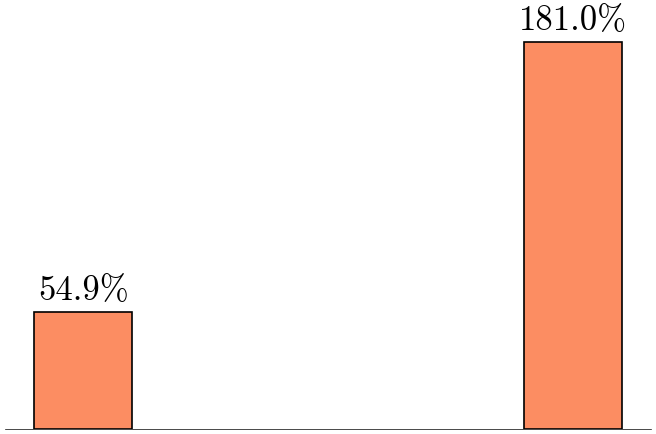

In [264]:
fig = plot_co2_uptake_across_evals(smape_df, train_groups=("DB1",), metric_type="SMAPE (%)")
fig.savefig("co2_uptake_DB1only_eval_DB1_DB2.png", dpi=300)

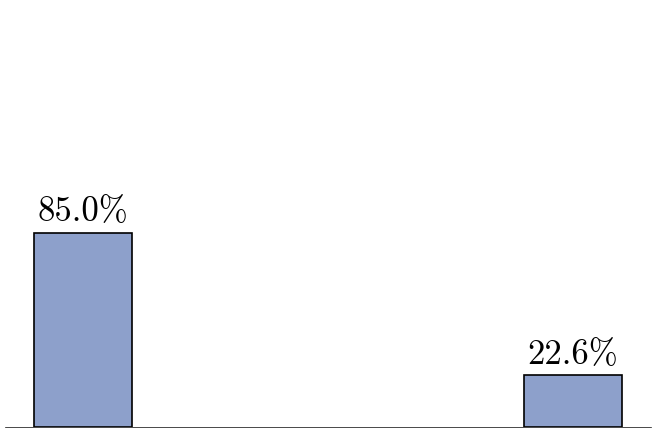

In [260]:
fig = plot_co2_uptake_across_evals(smape_df, train_groups=("DB2",), metric_type="SMAPE (%)")
fig.savefig("co2_uptake_DB2only_eval_DB1_DB2.png", dpi=300)

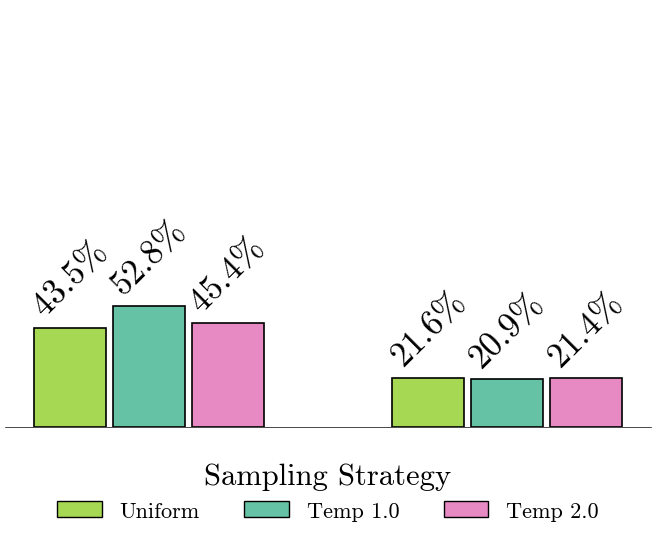

In [261]:
fig = plot_co2_uptake_across_evals(smape_df, train_groups=("Joint [DB1 + DB2]",), metric_type="SMAPE (%)")
fig.savefig("co2_uptake_joint_eval_DB1_DB2.png", dpi=300)